<a href="https://colab.research.google.com/github/manugd1105/AI_challenge_UPF/blob/main/Entrenamiento_y_testeo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NOTEBOOK 2/2

### Realizado por:

- Iker Lleida
- Santiago de León
- Manuel González

# Elección del modelo e hiperparámetros

Todo el trabajo lo vamos a desarrollar sobre el conjunto de train que teníamos. Este conjunto lo deividiremos en train (60%), validación (20%) y test (20%).

Lo primero que haremos será probar varios modelos entrenandolos en train y veremos con cual nos quedamos segun su performance en validación

In [ ]:
# Esto está montado para cargar el fichero desde drive al usar colab.
# Sino se tiene así, tambien dejamos en el repositorio el archivo df_train_manu
# Para que se pueda cargar de forma local

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/Reto de Inteligencia Artificial/df_train_manu.csv")

In [ ]:
df.head()

,audio_file,speaker_id,system_id,label_numerical,label_text,num_temporal_windows,mfcc_mean_0,mfcc_mean_1,mfcc_mean_2,mfcc_mean_3,...,mfcc_kurt_3,mfcc_kurt_4,mfcc_kurt_5,mfcc_kurt_6,mfcc_kurt_7,mfcc_kurt_8,mfcc_kurt_9,mfcc_kurt_10,mfcc_kurt_11,mfcc_kurt_12
0,/content/LA/ASVspoof2019_LA_train/flac/LA_T_11...,LA_0079,-,0,bonafide,109,-310.40796,43.036842,-18.052126,8.644586,...,1.309874,-0.983724,0.045031,-0.580553,-0.504889,-0.063759,-0.427871,-0.748618,-0.302753,1.553052
1,/content/LA/ASVspoof2019_LA_train/flac/LA_T_12...,LA_0079,-,0,bonafide,138,-330.95712,50.894707,-19.692842,10.769039,...,1.119556,-0.531304,-0.649178,-1.053209,-0.370049,-0.978057,-0.795056,0.493778,1.114291,-0.034808
2,/content/LA/ASVspoof2019_LA_train/flac/LA_T_12...,LA_0079,-,0,bonafide,91,-352.31696,18.402120,0.244028,8.822980,...,0.983940,0.011368,0.288825,0.926077,0.828593,-0.113401,-0.939718,-0.463290,-0.476926,-0.569304
3,/content/LA/ASVspoof2019_LA_train/flac/LA_T_12...,LA_0079,-,0,bonafide,88,-280.84598,48.768970,-7.991325,21.069437,...,-0.633393,-0.965992,-0.608938,0.734988,-0.698169,-0.910887,-0.984191,-0.787603,-0.192135,-1.100056
4,/content/LA/ASVspoof2019_LA_train/flac/LA_T_13...,LA_0079,-,0,bonafide,111,-301.70840,63.264990,-9.561450,-3.289454,...,0.150839,0.560195,-0.117506,-0.600111,-0.150093,-1.282657,-1.159197,-0.441457,-0.084253,0.779144


Tenemos que eliminar el system_id y el label_text porque determinan automaticamente la variable target label_numerical

Ademas, tambien vamos a eliminar audio_file y el speaker_ID ya que no aportan información a la prediccion y, ademas, si añadimos un nuevo registro (de una persona nueva), no vamos a tener valor de LA_0079 ni el sistema por el que fue generada su voz (lo que podría ocurrir en nuestro conjunto de test, en el cual pueden aparecen personas nuevas).

In [ ]:
df = df.drop(columns=['system_id', 'label_text', 'audio_file', 'speaker_id'])
df.head()

,label_numerical,num_temporal_windows,mfcc_mean_0,mfcc_mean_1,mfcc_mean_2,mfcc_mean_3,mfcc_mean_4,mfcc_mean_5,mfcc_mean_6,mfcc_mean_7,...,mfcc_kurt_3,mfcc_kurt_4,mfcc_kurt_5,mfcc_kurt_6,mfcc_kurt_7,mfcc_kurt_8,mfcc_kurt_9,mfcc_kurt_10,mfcc_kurt_11,mfcc_kurt_12
0,0,109,-310.40796,43.036842,-18.052126,8.644586,-30.472720,-6.541727,-12.117187,-9.478478,...,1.309874,-0.983724,0.045031,-0.580553,-0.504889,-0.063759,-0.427871,-0.748618,-0.302753,1.553052
1,0,138,-330.95712,50.894707,-19.692842,10.769039,-16.535870,-5.034311,-14.371912,-6.454690,...,1.119556,-0.531304,-0.649178,-1.053209,-0.370049,-0.978057,-0.795056,0.493778,1.114291,-0.034808
2,0,91,-352.31696,18.402120,0.244028,8.822980,-8.674293,-6.496036,-6.244439,-3.917905,...,0.983940,0.011368,0.288825,0.926077,0.828593,-0.113401,-0.939718,-0.463290,-0.476926,-0.569304
3,0,88,-280.84598,48.768970,-7.991325,21.069437,-34.162148,-4.567614,-8.792074,-16.917734,...,-0.633393,-0.965992,-0.608938,0.734988,-0.698169,-0.910887,-0.984191,-0.787603,-0.192135,-1.100056
4,0,111,-301.70840,63.264990,-9.561450,-3.289454,-17.743680,-2.535605,-13.747502,-12.589027,...,0.150839,0.560195,-0.117506,-0.600111,-0.150093,-1.282657,-1.159197,-0.441457,-0.084253,0.779144


Ahora vamos a dividir en train, validation y test; con el fin de utilizar la validation para comparar distintos tipos de modelos. De momento, en esta sección, dejamos test sin tocar para evitar data leakeage.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('label_numerical', axis=1)
y = df['label_numerical']

# Primer split: Dividir el conjunto original en entrenamiento y un conjunto temporal (que luego se dividirá en validación y test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

# Segundo split: Dividir el conjunto temporal en validación y test
# test_size=0.5 significa que el 50% de 'X_temp' (que es el 20% del total original) irá a test,
# y el otro 50% (otro 20% del total original) irá a validación.
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Tamaño del conjunto de entrenamiento: {len(X_train)} muestras")
print(f"Tamaño del conjunto de validación: {len(X_val)} muestras")
print(f"Tamaño del conjunto de test: {len(X_test)} muestras")

Tamaño del conjunto de entrenamiento: 15228 muestras
Tamaño del conjunto de validación: 5076 muestras
Tamaño del conjunto de test: 5076 muestras


Antes de entrenar modelos vamos a escalar los datos

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Convertir de nuevo a DataFrame si se desea mantener los nombres de las columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_val_scaled shape:", X_val_scaled.shape)

X_train_scaled shape: (15228, 92)
X_val_scaled shape: (5076, 92)


Ahora lo que haremos será probar varios modelos para predecir la y

En todos ellos se aplicaran 5 k-folds para hacer cross-validation y un gridsearch para optimizar los hiperparámetros sobre el conjunto de validación.

Es importante notar que, desde nuestro punto de vista de negocio, lo crítico (es decir, el peor escenario) será predecir que un audio es genuino (0) cuando realmente es fake (1), por lo que querremos maximizar el recall para la clase fake (1).

## Regresion logaritmica

Hiperparámetros a optimizar:

- C (Inverso de la fuerza de regularización): Controla la intensidad de la regularización. La regularización es una técnica que se utiliza para evitar el sobreajuste (overfitting) del modelo a los datos de entrenamiento.

- penalty (Tipo de regularización): Define el tipo de penalización que se aplica a los coeficientes del modelo.

  - l1 regularizacion Lasso: Puede llevar a que algunos coeficientes se reduzcan exactamente a cero, lo que efectivamente realiza una selección de características (elimina la influencia de algunas características).
  - l2 regularización Ridge: Tiende a reducir los coeficientes hacia cero, pero rara vez los hace exactamente cero. La regularización L2 es útil para manejar la multicolinealidad entre características.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, make_scorer, confusion_matrix, classification_report

# Definimos el modelo de Regresión Logistica
log_reg = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced') # Añadimos class_weight='balanced' para manejar un posible desbalanceo de clase

# Definimos el parametro grid para buscar
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Definimos la metrica de resultado: maximizando el retorno de clases positivas
# Esto nos ayuda a reducir los falsos negativos (Predecir 0 cuando es 1)
scorer = make_scorer(recall_score, pos_label=1)

# Establecemos 5-fold para el cross-validation
# Esto nos asegura que cada fold tenga aproximadamente el mismo porcentaje de muestras para cada clase objetivo
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Establecemos el GridSearchCV
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring=scorer,
    cv=skf,
    verbose=1,
    n_jobs=-1 # Usamos todos los cores disponibles
)

print("Iniciando Grid Search para Regresión Logística...")
# Ajustamos el GridSearchCV en los datos de train escalados
grid_search.fit(X_train_scaled, y_train)

print("\nGrid Search completado.")
# Sacamos los mejores parametros y resultados
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Mejores hiperparámetros encontrados: {best_params}")
print(f"Mejor score (recall en entrenamiento): {best_score:.4f}")

# Evaluamos el mejor modelo en el set de validación
best_log_reg_model = grid_search.best_estimator_

print("\nEvaluando el mejor modelo en el conjunto de validación...")
y_val_pred = best_log_reg_model.predict(X_val_scaled)

# Imprimimos las metricas de validación
print("\nClassification Report en el conjunto de validación:")
print(classification_report(y_val, y_val_pred))

print("\nMatriz de Confusión en el conjunto de validación:")
print(confusion_matrix(y_val, y_val_pred))

Iniciando Grid Search para Regresión Logística...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Grid Search completado.
Mejores hiperparámetros encontrados: {'C': 10, 'penalty': 'l1'}
Mejor score (recall en entrenamiento): 0.9100

Evaluando el mejor modelo en el conjunto de validación...

Classification Report en el conjunto de validación:
              precision    recall  f1-score   support

           0       0.55      0.93      0.69       516
           1       0.99      0.91      0.95      4560

    accuracy                           0.91      5076
   macro avg       0.77      0.92      0.82      5076
weighted avg       0.95      0.91      0.92      5076


Matriz de Confusión en el conjunto de validación:
[[ 479   37]
 [ 398 4162]]


## Decission Tree Classifier

Hiperparámetros a optimizar:

- max_depth: Número máximo de ramificaciones

- min_samples_leaf: Numero mínimo de samples necesarios para generar una ramificación

- criterion: Función para medir la calidad de cada ramificación

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, make_scorer, confusion_matrix, classification_report

#  Definimos el modelo Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42, class_weight='balanced') # Added class_weight='balanced'

# Definimos el parametro grid para buscar
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None], # Max depth of the tree, None means unlimited
    'min_samples_leaf': [1, 5, 10, 20], # Minimum number of samples required to be at a leaf node
    'criterion': ['gini', 'entropy'] # Function to measure the quality of a split
}

# Definimos la metrica de resultado: maximizando el retorno de clases positivas
scorer = make_scorer(recall_score, pos_label=1)

# Establecemos 5-fold para el cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Establecemos el GridSearchCV
grid_search_dt = GridSearchCV(
    estimator=dt_classifier,
    param_grid=param_grid_dt,
    scoring=scorer,
    cv=skf,
    verbose=1,
    n_jobs=-1 # Usamos todos los cores disponibles
)

print("Iniciando Grid Search para Decision Tree Classifier...")
# Ajustamos el GridSearchCV en los datos de train escalados
grid_search_dt.fit(X_train_scaled, y_train)

print("\nGrid Search completado para Decision Tree Classifier.")
# Sacamos los mejores parametros y resultados
best_params_dt = grid_search_dt.best_params_
best_score_dt = grid_search_dt.best_score_

print(f"Mejores hiperparámetros encontrados para Decision Tree: {best_params_dt}")
print(f"Mejor score (recall en entrenamiento) para Decision Tree: {best_score_dt:.4f}")

# Evaluamos el mejor modelo en el set de validación
best_dt_model = grid_search_dt.best_estimator_

print("\nEvaluando el mejor modelo de Decision Tree en el conjunto de validación...")
y_val_pred_dt = best_dt_model.predict(X_val_scaled)

# Imprimimos las metricas de validación
print("\nClassification Report en el conjunto de validación para Decision Tree:")
print(classification_report(y_val, y_val_pred_dt))

print("\nMatriz de Confusión en el conjunto de validación para Decision Tree:")
print(confusion_matrix(y_val, y_val_pred_dt))

Iniciando Grid Search para Decision Tree Classifier...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Grid Search completado para Decision Tree Classifier.
Mejores hiperparámetros encontrados para Decision Tree: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1}
Mejor score (recall en entrenamiento) para Decision Tree: 0.9645

Evaluando el mejor modelo de Decision Tree en el conjunto de validación...

Classification Report en el conjunto de validación para Decision Tree:
              precision    recall  f1-score   support

           0       0.66      0.62      0.64       516
           1       0.96      0.96      0.96      4560

    accuracy                           0.93      5076
   macro avg       0.81      0.79      0.80      5076
weighted avg       0.93      0.93      0.93      5076


Matriz de Confusión en el conjunto de validación para Decision Tree:
[[ 322  194]
 [ 163 4397]]


## Random Forest Classifier

Hiperparámetros a optimizar:

- n_estimators: Número de árboles de decisión en el Random Forest.

- max_depth: Máximo número de ramificaciones en cada árbol de decisión.

- min_samples_leaf: Mínimo número de samples necesarios para generar una ramificación.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, make_scorer, confusion_matrix, classification_report

# Definimos el modelo Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42, class_weight='balanced') # Added class_weight='balanced'

# Definimos el parametro grid para buscar
param_grid_rf = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [5, 10, None],      # Maximum depth of the tree
    'min_samples_leaf': [1, 5, 10]   # Minimum number of samples required to be at a leaf node
}

# # Definimos la metrica de resultado: maximizando el retorno de clases positivas
scorer = make_scorer(recall_score, pos_label=1)

# Establecemos 5-fold para el cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Establecemos el GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=rf_classifier,
    param_grid=param_grid_rf,
    scoring=scorer,
    cv=skf,
    verbose=1,
    n_jobs=-1 # Usamos todos los cores disponibles
)

print("Iniciando Grid Search para Random Forest Classifier...")
# Ajustamos el GridSearchCV en los datos de train escalados
grid_search_rf.fit(X_train_scaled, y_train)

print("\nGrid Search completado para Random Forest Classifier.")
# Sacamos los mejores parametros y resultados
best_params_rf = grid_search_rf.best_params_
best_score_rf = grid_search_rf.best_score_

print(f"Mejores hiperparámetros encontrados para Random Forest: {best_params_rf}")
print(f"Mejor score (recall en entrenamiento) para Random Forest: {best_score_rf:.4f}")

# Evaluamos el mejor modelo en el set de validación
best_rf_model = grid_search_rf.best_estimator_

print("\nEvaluando el mejor modelo de Random Forest en el conjunto de validación...")
y_val_pred_rf = best_rf_model.predict(X_val_scaled)

# Imprimimos las metricas de validación
print("\nClassification Report en el conjunto de validación para Random Forest:")
print(classification_report(y_val, y_val_pred_rf))

print("\nMatriz de Confusión en el conjunto de validación para Random Forest:")
print(confusion_matrix(y_val, y_val_pred_rf))

Iniciando Grid Search para Random Forest Classifier...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Grid Search completado para Random Forest Classifier.
Mejores hiperparámetros encontrados para Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Mejor score (recall en entrenamiento) para Random Forest: 0.9973

Evaluando el mejor modelo de Random Forest en el conjunto de validación...

Classification Report en el conjunto de validación para Random Forest:
              precision    recall  f1-score   support

           0       0.96      0.57      0.72       516
           1       0.95      1.00      0.97      4560

    accuracy                           0.95      5076
   macro avg       0.96      0.78      0.85      5076
weighted avg       0.95      0.95      0.95      5076


Matriz de Confusión en el conjunto de validación para Random Forest:
[[ 294  222]
 [  12 4548]]


## Support Vector Machine (SVM)

Hiperparámetros a probar:

- C (Parámetro de regularización): Idem a regresion logistica

- kernel: Función matemática que toma tus datos y los proyecta a una dimensión geométrica superior donde sí se puedan separar fácilmente

- gamma: Solo entra en juego cuando se usan kernels no lineales (como el rbf). Define qué tan lejos llega la influencia de un solo punto de dato en el entrenamiento.

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, make_scorer, confusion_matrix, classification_report

# Establecemos el modelo de Suport Vector Classifier
svm_classifier = SVC(random_state=42, class_weight='balanced') # Agregamos la class_weight='balanced'

# Definimos el parametro de grid para buscar
# Empezamos con tamaños mas pequeños por el potencial costo de computación del SVM
param_grid_svm = {
    'C': [0.1, 1, 10],  # Regularizamos parametros
    'kernel': ['linear', 'rbf'], # Especificamos los tipos de kernel
    'gamma': ['scale', 'auto'] # Coeficiente de Kernel para "rbf"
}

# Definimos la metrica de resultado: maximizando el retorno de clases positivas
scorer = make_scorer(recall_score, pos_label=1)

# Establecemos 5-fold para el cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Establecemos el GridSearchCV
grid_search_svm = GridSearchCV(
    estimator=svm_classifier,
    param_grid=param_grid_svm,
    scoring=scorer,
    cv=skf,
    verbose=1,
    n_jobs=-1 # Usamos todos los cores disponibles
)

print("Iniciando Grid Search para SVM Classifier...")
# Ajustamos el GridSearchCV en los datos de train escalados
grid_search_svm.fit(X_train_scaled, y_train)

print("\nGrid Search completado para SVM Classifier.")
# Sacamos los mejores parametros y resultados
best_params_svm = grid_search_svm.best_params_
best_score_svm = grid_search_svm.best_score_

print(f"Mejores hiperparámetros encontrados para SVM: {best_params_svm}")
print(f"Mejor score (recall en entrenamiento): {best_score_svm:.4f}")

# Evaluamos el mejor modelo en el set de validación
best_svm_model = grid_search_svm.best_estimator_

print("\nEvaluando el mejor modelo de SVM en el conjunto de validación...")
y_val_pred_svm = best_svm_model.predict(X_val_scaled)

# Imprimimos las metricas de validación
print("\nClassification Report en el conjunto de validación para SVM:")
print(classification_report(y_val, y_val_pred_svm))

print("\nMatriz de Confusión en el conjunto de validación para SVM:")
print(confusion_matrix(y_val, y_val_pred_svm))

Iniciando Grid Search para SVM Classifier...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Grid Search completado para SVM Classifier.
Mejores hiperparámetros encontrados para SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Mejor score (recall en entrenamiento): 0.9954

Evaluando el mejor modelo de SVM en el conjunto de validación...

Classification Report en el conjunto de validación para SVM:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       516
           1       0.99      1.00      0.99      4560

    accuracy                           0.99      5076
   macro avg       0.98      0.97      0.97      5076
weighted avg       0.99      0.99      0.99      5076


Matriz de Confusión en el conjunto de validación para SVM:
[[ 487   29]
 [  20 4540]]


## k-NN

Hiperparámetros a optimizar:

- n_neighbors: Número de vecinos más cercanos a considerar para la clasificación.

- weights: Define cómo se pondera cada uno de los n_neighbors vecinos en la decisión de clasificación:

  - 'uniform': Todos los puntos de datos considerados como vecinos tienen la misma influencia en la decisión de clasificación.

  - 'distance': Los puntos más cercanos al punto de consulta tienen una mayor influencia en la decisión que los puntos más lejanos. La influencia es inversamente proporcional a la distancia del punto de consulta.

- metric: Especifica la función de distancia utilizada para medir la proximidad entre los puntos de datos.

  - 'euclidean': Es la distancia en línea recta entre dos puntos en un espacio euclidiano (es decir, la distancia derivada de la metríca usual).

  - 'manhattan': Es la suma de las diferencias absolutas de las coordenadas entre dos puntos.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, make_scorer, confusion_matrix, classification_report

# Definimos el modelo K-NN
# k-NN no tiene una clase directa "class_weight" como los demas modelos
# El desbalanceo de clases se puede a veces manejar por "weights="distance""
# o con over o undersampling.
# Pero por ahora nos quedamos con el preestablecido "uniform" weigths pudiendo usar "distance" de ser necesario.
knn_classifier = KNeighborsClassifier()

# # Definimos el parametro grid para buscar
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15], # Numero de vecinos a considerar
    'weights': ['uniform', 'distance'],      # Función Weight function usada en predicción
    'metric': ['euclidean', 'manhattan']     # Métrica distancia
}

# # Definimos la metrica de resultado: maximizando el retorno de clases positivas
scorer = make_scorer(recall_score, pos_label=1)

# Establecemos 5-fold para el cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Establecemos el GridSearchCV
grid_search_knn = GridSearchCV(
    estimator=knn_classifier,
    param_grid=param_grid_knn,
    scoring=scorer,
    cv=skf,
    verbose=1,
    n_jobs=-1  # Usamos todos los cores disponibles
)

print("Iniciando Grid Search para k-NN Classifier...")

# Ajustamos el GridSearchCV en los datos de train escalados
grid_search_knn.fit(X_train_scaled, y_train)

print("\nGrid Search completado para k-NN Classifier.")
# Sacamos los mejores parametros y resultados
best_params_knn = grid_search_knn.best_params_
best_score_knn = grid_search_knn.best_score_

print(f"Mejores hiperparámetros encontrados para k-NN: {best_params_knn}")
print(f"Mejor score (recall en entrenamiento) para k-NN: {best_score_knn:.4f}")

# Evaluamos el mejor modelo en el set de validación
best_knn_model = grid_search_knn.best_estimator_

print("\nEvaluando el mejor modelo de k-NN en el conjunto de validación...")
y_val_pred_knn = best_knn_model.predict(X_val_scaled)

# Imprimimos las metricas de validación
print("\nClassification Report en el conjunto de validación para k-NN:")
print(classification_report(y_val, y_val_pred_knn))

print("\nMatriz de Confusión en el conjunto de validación para k-NN:")
print(confusion_matrix(y_val, y_val_pred_knn))

Iniciando Grid Search para k-NN Classifier...
Fitting 5 folds for each of 28 candidates, totalling 140 fits

Grid Search completado para k-NN Classifier.
Mejores hiperparámetros encontrados para k-NN: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
Mejor score (recall en entrenamiento) para k-NN: 0.9942

Evaluando el mejor modelo de k-NN en el conjunto de validación...

Classification Report en el conjunto de validación para k-NN:
              precision    recall  f1-score   support

           0       0.96      0.84      0.90       516
           1       0.98      1.00      0.99      4560

    accuracy                           0.98      5076
   macro avg       0.97      0.92      0.94      5076
weighted avg       0.98      0.98      0.98      5076


Matriz de Confusión en el conjunto de validación para k-NN:
[[ 434   82]
 [  16 4544]]


## XG-Boost

Hiperparámetros a optimizar:

- n_estimators: Define el número de árboles de regresión que se construirán en el modelo. Cada árbol corrige los errores del anterior.

- learning_rate: Controla el tamaño del paso de la reducción de pesos de cada árbol. Un valor bajo hace que el modelo sea más robusto a sobreajuste, pero requiere un mayor número de n_estimators y más tiempo de entrenamiento. Un valor alto puede llevar a un sobreajuste o a que el modelo no converja.

- max_depth: Idem a Decision Tree Classifier

- subsample: Especifica la fracción de muestras (filas) que se utilizan para entrenar cada árbol.

- colsample_bytree: Define la fracción de características que se seleccionan aleatoriamente para construir cada árbol.

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, make_scorer, confusion_matrix, classification_report

# Definimos el modelo XGBoost
# Usamos scale_pos_weight para lidiar con el desbalanceo de clases, calculando basandonos en y_train
scale_pos_weight_value = (y_train == 0).sum() / (y_train == 1).sum()
xgb_classifier = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    scale_pos_weight=scale_pos_weight_value
)

# Definimos el parametro grid para buscar
param_grid_xgb = {
    'n_estimators': [100, 200, 300],  # Number of boosting rounds
    'learning_rate': [0.01, 0.1, 0.2], # Step size shrinkage to prevent overfitting
    'max_depth': [3, 5, 7],           # Maximum depth of a tree
    'subsample': [0.7, 0.9],          # Subsample ratio of the training instance
    'colsample_bytree': [0.7, 0.9]    # Subsample ratio of columns when constructing each tree
}

# Definimos la metrica de resultado: maximizando el retorno de clases positivas
scorer = make_scorer(recall_score, pos_label=1)

# Establecemos 5-fold para el cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Establecemos el GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=xgb_classifier,
    param_grid=param_grid_xgb,
    scoring=scorer,
    cv=skf,
    verbose=1,
    n_jobs=-1 # Usamos todos los cores disponibles
)

print("Iniciando Grid Search para XGBoost Classifier...")

# Ajustamos el GridSearchCV en los datos de train escalados
grid_search_xgb.fit(X_train_scaled, y_train)

print("\nGrid Search completado para XGBoost Classifier.")
# Sacamos los mejores parametros y resultados
best_params_xgb = grid_search_xgb.best_params_
best_score_xgb = grid_search_xgb.best_score_

print(f"Mejores hiperparámetros encontrados para XGBoost: {best_params_xgb}")
print(f"Mejor score (recall en entrenamiento): {best_score_xgb:.4f}")

# Evaluamos el mejor modelo en el set de validación
best_xgb_model = grid_search_xgb.best_estimator_

print("\nEvaluando el mejor modelo de XGBoost en el conjunto de validación...")
y_val_pred_xgb = best_xgb_model.predict(X_val_scaled)

# Imprimimos las metricas de validación
print("\nClassification Report en el conjunto de validación para XGBoost:")
print(classification_report(y_val, y_val_pred_xgb))

print("\nMatriz de Confusión en el conjunto de validación para XGBoost:")
print(confusion_matrix(y_val, y_val_pred_xgb))

Iniciando Grid Search para XGBoost Classifier...
Fitting 5 folds for each of 108 candidates, totalling 540 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:14:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Grid Search completado para XGBoost Classifier.
Mejores hiperparámetros encontrados para XGBoost: {'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.9}
Mejor score (recall en entrenamiento): 0.9917

Evaluando el mejor modelo de XGBoost en el conjunto de validación...

Classification Report en el conjunto de validación para XGBoost:
              precision    recall  f1-score   support

           0       0.93      0.92      0.93       516
           1       0.99      0.99      0.99      4560

    accuracy                           0.99      5076
   macro avg       0.96      0.96      0.96      5076
weighted avg       0.98      0.99      0.98      5076


Matriz de Confusión en el conjunto de validación para XGBoost:
[[ 474   42]
 [  34 4526]]


## Redes Neuronales

Hiperparámetros a probar (aunque realmente los dos últimos los fijamos a un valor):

- hidden_layer_sizes: Define la arquitectura de las capas ocultas de la red neuronal. Es una n-tupla donde cada elemento representa el número de neuronas en una capa oculta específica (constando la red neuronal de un total de n capas ocultas).

- activation: Especifica la función de activación para las capas ocultas. Las funciones de activación introducen no linealidad en el modelo, siendo algunas opciones:

  - 'relu' (Rectified Linear Unit): Devuelve 0 si la entrada es negativa y la entrada misma si es positiva.

  - 'tanh' (Tangente hiperbólica): Comprime los valores de entrada entre -1 y 1.

- alpha: Parámetro de regularización L2. Su objetivo es prevenir el sobreajuste reduciendo la magnitud de los pesos de la red.

- solver: Especifica el algoritmo utilizado para la optimización de los pesos de la red neuronal. Solo probaremos con adam ya que es el más popular y generalmente aceptado.

- max_iter: Define el número máximo de épocas (iteraciones o pasadas completas sobre el conjunto de entrenamiento) que el algoritmo de optimización realizará. Lo fijaremos en 200 que es un número suficientemente grande

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, make_scorer, confusion_matrix, classification_report

# Definimos el modelo MLPClassifier
# Establecemos el random_state para reproducibilidad
# Establecemos early_stopping=True para dejar de entrenar cuando el marcador de validación no mejore
mlp_classifier = MLPClassifier(random_state=42, early_stopping=True, n_iter_no_change=10)

# Definimos el parametro grid para buscar
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)], # Una capa oculta con 50 o 100 neuronas o dos capas con 50 neuronas
    'activation': ['relu', 'tanh'],               # Función de activación para la capa oculta
    'alpha': [0.0001, 0.001, 0.01],               # L2 penalty parametro de regularización
    'solver': ['adam'],                           # Solver para optimización de weight (adam es comunmente bueno)
    'max_iter': [200]                             # Numero maximo de iteraciones
}

# Definimos la metrica de resultado: maximizando el retorno de clases positivas
scorer = make_scorer(recall_score, pos_label=1)

# Establecemos 5-fold para el cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Establecemos el GridSearchCV
grid_search_mlp = GridSearchCV(
    estimator=mlp_classifier,
    param_grid=param_grid_mlp,
    scoring=scorer,
    cv=skf,
    verbose=1,
    n_jobs=-1  # Use todos los cores disponibles
)

print("Iniciando Grid Search para MLP Classifier (Red Neuronal)...")

# Ajustamos el GridSearchCV en los datos de train escalados
grid_search_mlp.fit(X_train_scaled, y_train)

print("\nGrid Search completado para MLP Classifier (Red Neuronal).")
# Sacamos los mejores parametros y resultados
best_params_mlp = grid_search_mlp.best_params_
best_score_mlp = grid_search_mlp.best_score_

print(f"Mejores hiperparámetros encontrados para MLP Classifier: {best_params_mlp}")
print(f"Mejor score (recall en entrenamiento) para MLP Classifier: {best_score_mlp:.4f}")

# Evaluamos el mejor modelo en el set de validación
best_mlp_model = grid_search_mlp.best_estimator_

print("\nEvaluando el mejor modelo de MLP Classifier en el conjunto de validación...")
y_val_pred_mlp = best_mlp_model.predict(X_val_scaled)

# Imprimimos las metricas de validación
print("\nClassification Report en el conjunto de validación para MLP Classifier:")
print(classification_report(y_val, y_val_pred_mlp))

print("\nMatriz de Confusión en el conjunto de validación para MLP Classifier:")
print(confusion_matrix(y_val, y_val_pred_mlp))

Iniciando Grid Search para MLP Classifier (Red Neuronal)...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Grid Search completado para MLP Classifier (Red Neuronal).
Mejores hiperparámetros encontrados para MLP Classifier: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'max_iter': 200, 'solver': 'adam'}
Mejor score (recall en entrenamiento) para MLP Classifier: 0.9939

Evaluando el mejor modelo de MLP Classifier en el conjunto de validación...

Classification Report en el conjunto de validación para MLP Classifier:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       516
           1       0.99      0.99      0.99      4560

    accuracy                           0.99      5076
   macro avg       0.97      0.97      0.97      5076
weighted avg       0.99      0.99      0.99      5076


Matriz de Confusión en el conjunto de validación para MLP Classifier:
[[ 486   30]
 [  23 4537]]


# Balanceo de datos y decisión final

Bajo el criterio que buscábamos, el modelo que más ha reducido los falsos positivos (es decir, ha maximizado el recall) ha sido el Random Forest Classifier con los hiperparámetros optimizados (11 FP). No obstante, observamos que ese modelo el número de FN es muy elevado, por lo que el modelo está prediciendo casi siempre la clase mayoritaria (es decir, 1=fake). Para ver la calidad real de los modelos, vamos a realizar un balanceo de los datos (con undersampling) y repetir el entrenamiento del modelo óptimo encontrado. Además, el siguiente modelo con menor número de FP es SVM con 20, y en este también se observan muy pocos FN. También vamos a reentrenar este modelo con el undersampling hecho para ver si varía.

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

print("Distribución original de las clases en y_train:", Counter(y_train))

# Empezamos RandomUnderSampler
# random_state para reproducibilidad
# sampling_strategy='auto' balancea la mayoria de clases y la minoria de clases
undersampler = RandomUnderSampler(random_state=42, sampling_strategy='auto')

# Aplicamos undersampling a X_train y a y_train
X_train_resampled, y_train_resampled = undersampler.fit_resample(X_train_scaled, y_train)

print("Distribución de las clases en y_train después de undersampling:", Counter(y_train_resampled))
print(f"Dimensiones de X_train después de undersampling: {X_train_resampled.shape}")
print(f"Dimensiones de y_train después de undersampling: {y_train_resampled.shape}")

Distribución original de las clases en y_train: Counter({1: 13680, 0: 1548})
Distribución de las clases en y_train después de undersampling: Counter({0: 1548, 1: 1548})
Dimensiones de X_train después de undersampling: (3096, 92)
Dimensiones de y_train después de undersampling: (3096,)


Modelo Random Forest entrenado con éxito usando datos balanceados.

Classification Report en el conjunto de validación para Random Forest con datos rebalanceados:
              precision    recall  f1-score   support

           0       0.56      0.95      0.71       516
           1       0.99      0.92      0.95      4560

    accuracy                           0.92      5076
   macro avg       0.78      0.93      0.83      5076
weighted avg       0.95      0.92      0.93      5076


Matriz de Confusión en el conjunto de validación para Random Forest con datos rebalanceados:
[[ 490   26]
 [ 381 4179]]


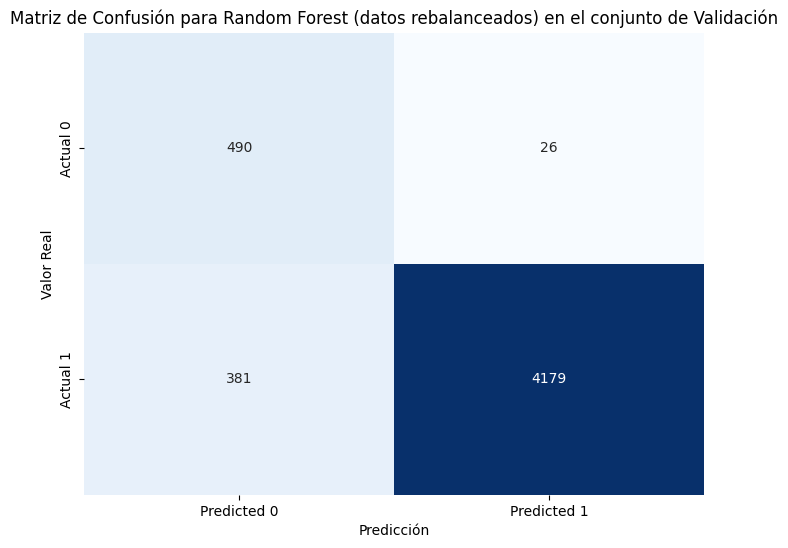

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Los mejores hiperparametros para Random forest encontrados con GridSearchCV fueron guardados en best_params_rf
# best_params_rf = {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}

# Iniciamos el Random Forest Classifier con hyperparametros optimos
# y lo entrenamos con los datos remuestreados
rf_resampled = RandomForestClassifier(
    n_estimators=best_params_rf['n_estimators'],
    max_depth=best_params_rf['max_depth'],
    min_samples_leaf=best_params_rf['min_samples_leaf'],
    random_state=42, # Aseguramos reproducibilidad
    class_weight='balanced', # Importante usarlo con datos desbalanceados incluso despues de remuestrear
    n_jobs=-1 # Usamos los cores disponibles
)

# Entrenamos el modelo con los datos remuestreados de train
rf_resampled.fit(X_train_resampled, y_train_resampled)

print("Modelo Random Forest entrenado con éxito usando datos balanceados.")

# Evaluamos el modelo con el set de validación (datos escalados)
y_val_pred_resampled_rf = rf_resampled.predict(X_val_scaled)

# Imprimimos metricas de validación
print("\nClassification Report en el conjunto de validación para Random Forest con datos rebalanceados:")
print(classification_report(y_val, y_val_pred_resampled_rf))

print("\nMatriz de Confusión en el conjunto de validación para Random Forest con datos rebalanceados:")
cm_resampled_rf = confusion_matrix(y_val, y_val_pred_resampled_rf)
print(cm_resampled_rf)

# Ploteamos la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_resampled_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Matriz de Confusión para Random Forest (datos rebalanceados) en el conjunto de Validación')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

Como habíamos predicho, el modelo estaba memorizando más que aprendiendo, ya que al balancear los datos en train (pero no en validation) la recall de la clase 1 cae claramente

Vamos a hacer lo mismmo con el SVM

Modelo SVM entrenado con éxito usando datos balanceados.

Classification Report en el conjunto de validación para SVM con datos rebalanceados:
              precision    recall  f1-score   support

           0       0.79      0.98      0.87       516
           1       1.00      0.97      0.98      4560

    accuracy                           0.97      5076
   macro avg       0.89      0.97      0.93      5076
weighted avg       0.98      0.97      0.97      5076


Matriz de Confusión en el conjunto de validación para SVM con datos rebalanceados:
[[ 504   12]
 [ 137 4423]]


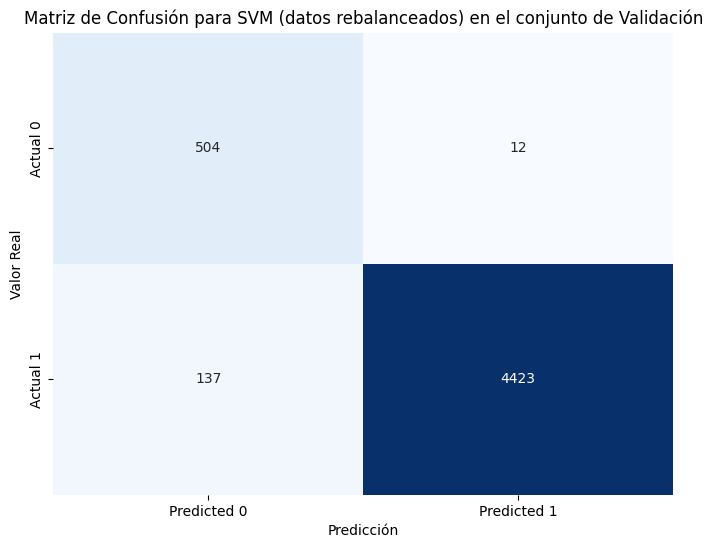

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Mejores hyperparametros para SVM encontrados en el GridSearchvCV fueron guardados en best_params_svm
# best_params_svm = {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

# Iniciamos el SVM Classifier con hyperparametros optimos
# y lo entrenamos con los datos remuestreados
svm_resampled = SVC(
    C=best_params_svm['C'],
    kernel=best_params_svm['kernel'],
    gamma=best_params_svm['gamma'],
    random_state=42, # Aseguramos reproducibilidad
    class_weight='balanced' # Importante que sean datos desbalanceados
)

# Entrenamos el modelo con los datos remuestreados de train
svm_resampled.fit(X_train_resampled, y_train_resampled)

print("Modelo SVM entrenado con éxito usando datos balanceados.")

# Evaluamos el modelo con el set de validación (datos escalados)
y_val_pred_resampled_svm = svm_resampled.predict(X_val_scaled)

# Imprimimos metricas de validación
print("\nClassification Report en el conjunto de validación para SVM con datos rebalanceados:")
print(classification_report(y_val, y_val_pred_resampled_svm))

print("\nMatriz de Confusión en el conjunto de validación para SVM con datos rebalanceados:")
cm_resampled_svm = confusion_matrix(y_val, y_val_pred_resampled_svm)
print(cm_resampled_svm)

# Ploteamos la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_resampled_svm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Matriz de Confusión para SVM (datos rebalanceados) en el conjunto de Validación')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

Aquí con el SVM también vemos que cae un poco al balancearlo, pero es mucho más moderado. Por ello, vamos a decedir seguir hacia delante seleccinando el SVM balanceado como el mejor modelo.

# Entrenamiento del modelo final y evaluación en test

Ahora, construimos el conjunto de train final (df_train + df_val anterior), y después lo balancearemos

In [ ]:
import pandas as pd

# Concatenamos X_train y X_val para crear el training final
X_train_final = pd.concat([X_train, X_val], ignore_index=True)

# Concatenamos y_train y y_val para crear el training final
y_train_final = pd.concat([y_train, y_val], ignore_index=True)

print(f"Dimensiones de X_train_final: {X_train_final.shape}")
print(f"Dimensiones de y_train_final: {y_train_final.shape}")

Dimensiones de X_train_final: (20304, 92)
Dimensiones de y_train_final: (20304,)


In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

print("Distribución original de las clases en y_train_final:", Counter(y_train_final))

# Iniciamos RandomUnderSampler
# random_state para reproducibilidad
# sampling_strategy='auto' balancea la mayoria y minoria de clases
undersampler = RandomUnderSampler(random_state=42, sampling_strategy='auto')

# Aplicamos undersampling a to X_train_final y tambien a y_train_final
X_train_final_resampled, y_train_final_resampled = undersampler.fit_resample(X_train_final, y_train_final)

print("Distribución de las clases en y_train_final después de undersampling:", Counter(y_train_final_resampled))
print(f"Dimensiones de X_train_final después de undersampling: {X_train_final_resampled.shape}")
print(f"Dimensiones de y_train_final después de undersampling: {y_train_final_resampled.shape}")

Distribución original de las clases en y_train_final: Counter({1: 18240, 0: 2064})
Distribución de las clases en y_train_final después de undersampling: Counter({0: 2064, 1: 2064})
Dimensiones de X_train_final después de undersampling: (4128, 92)
Dimensiones de y_train_final después de undersampling: (4128,)


Como vamos a utilizar un SVM, es esencial escalar.

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Iniciamos un nuevo StandardScaler
final_scaler = StandardScaler()

# Ajustamos el escalado en los datos remuestreados finales de training
X_train_final_resampled_scaled = final_scaler.fit_transform(X_train_final_resampled)

# Transformamos los datos de test usados para el fitted scaler
X_test_scaled = final_scaler.transform(X_test)

# Convertimos los escalados de vuelta a DataFrames, conservando el nombre de las columnas
X_train_final_resampled_scaled = pd.DataFrame(X_train_final_resampled_scaled, columns=X_train_final_resampled.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Dimensiones de X_train_final_resampled_scaled:", X_train_final_resampled_scaled.shape)
print("Dimensiones de X_test_scaled:", X_test_scaled.shape)

Dimensiones de X_train_final_resampled_scaled: (4128, 92)
Dimensiones de X_test_scaled: (5076, 92)


Lo que vamos a hacer ahora es encontrar el número de datos necesarios para entrenar el modelo final. Para ello, haremos una curva de aprendizaje del modelo. Recordamos que los parámetros óptimos encontrados son:

- 'C': 10
- 'gamma': 'scale'
- 'kernel': 'rbf'

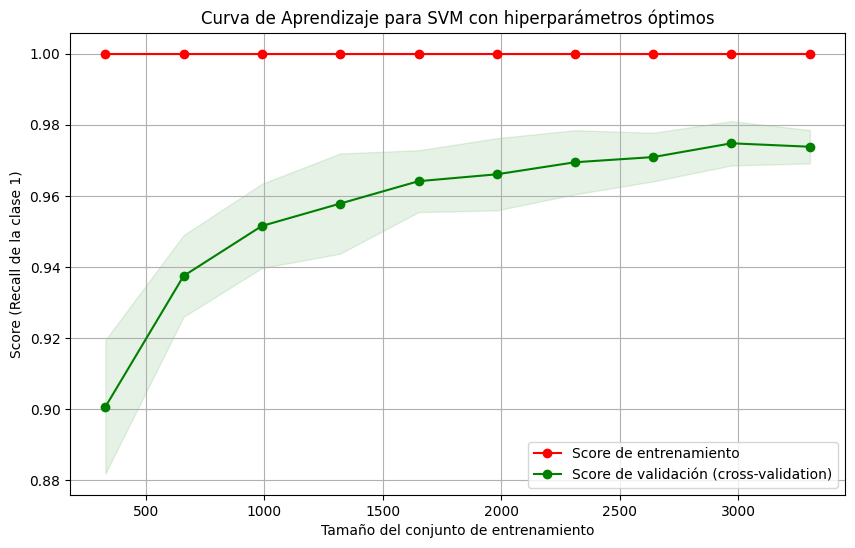

Último score promedio de entrenamiento: 1.0000
Último score promedio de validación: 0.9738


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import recall_score, make_scorer
from sklearn.utils import shuffle # Import shuffle

# Definimos el Support Vector Classifier con hyperparametros optimos encontrados previamente
# best_params_svm = {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
svm_classifier_lc = SVC(
    C=best_params_svm['C'],
    kernel=best_params_svm['kernel'],
    gamma=best_params_svm['gamma'],
    random_state=42,
    class_weight='balanced' # Dejamos class_weight balanceado como en el remuestreo de datos
)

# Definimos la metrica de resultado: maximizando el retorno de clases positivas
scorer = make_scorer(recall_score, pos_label=1)

# Establecemos 5-fold para el cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Importante: Mezclar los datos explicitamente despues del undersampling para evitar errores
# Algunas muestras iniciales puede pertenecer fuertemente a una clase
# Esto nos asegura que la curva de aprendizaje tome en cuenta un buen dataset
X_shuffled, y_shuffled = shuffle(X_train_final_resampled_scaled, y_train_final_resampled, random_state=42)

# Generamos los datos de la curva de aprendizaje
train_sizes, train_scores, test_scores = learning_curve(
    svm_classifier_lc,
    X_shuffled, # Usamos datos mezclados
    y_shuffled, # Usamos datos mezclados
    cv=skf, # Establecemos 5-fold para el cross-validation
    scoring=scorer,
    n_jobs=-1, # Usamos los cores disponibles
    train_sizes=np.linspace(0.1, 1.0, 10), # Usamos los 10 tamaños diferentes del 10% al 100% de los datos entrenados
    random_state=42
)

# Calculamos media y desviación estandar de los resultados de training y test
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Ploteamos la curva de aprendizaje
plt.figure(figsize=(10, 6))
plt.title("Curva de Aprendizaje para SVM con hiperparámetros óptimos")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Score (Recall de la clase 1)")
plt.grid()

plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1,
                 color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1,
                 color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
         label="Score de entrenamiento")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
         label="Score de validación (cross-validation)")

plt.legend(loc="best")
plt.show()

print(f"Último score promedio de entrenamiento: {train_scores_mean[-1]:.4f}")
print(f"Último score promedio de validación: {test_scores_mean[-1]:.4f}")

Podemos observar en la curva que a partir de 3000 datos en el entrenamiento que la curva alcanza su máximo y ya no mejora, por lo que utilizaremos dicha cantidad de datos en el conjunto de train.

Se observa un ligero overfitting, ya que todos los datos de entrenamiento los memoriza perfectamente. No obstante, esto es muy asumible, ya que en los datos nuevos solo baja menos de un 0.03 en recall.



Con este modelo, vamos a plotear unas cuantas métricas y gráficas para visualizar mejor la performance de nuestro modelo y las features más importantes.

In [ ]:
from sklearn.svm import SVC

# Optimizamos hyperparametros para el SVM enconrado anteriormente
# best_params_svm = {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

# Iniciamos el modelo final de SVM con hyperparametros optimos
modelo_final = SVC(
    C=best_params_svm['C'],
    kernel=best_params_svm['kernel'],
    gamma=best_params_svm['gamma'],
    random_state=42,
    class_weight='balanced' # Dejamos la class_weight balanceada como en los pasos anteriores
)

# Seleccionamos las primeras 3000 muestras de X_shuffled y de y_shuffled
# X_shuffled y y_shuffled ya estan escaladas,remuestreadas y mezcladas
X_train_3000 = X_shuffled.head(3000)
y_train_3000 = y_shuffled.head(3000)

# Entrenamos el modelo final
modelo_final.fit(X_train_3000, y_train_3000)

print("Modelo 'modelo_final' (SVM) entrenado con éxito usando 3000 datos de X_shuffled.")

Modelo 'modelo_final' (SVM) entrenado con éxito usando 3000 datos de X_shuffled.


## Matriz de confusión

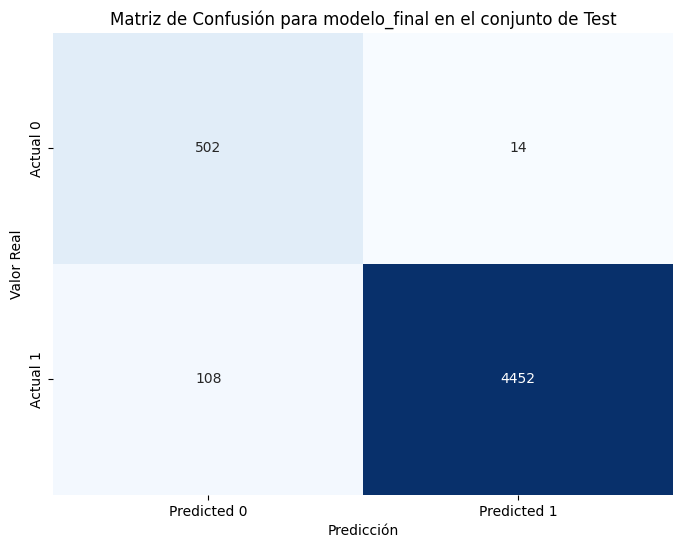

Matriz de Confusión:
[[ 502   14]
 [ 108 4452]]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd

# Hacemos predicciones en el set de testeo procesado usando el modelo final
y_pred = modelo_final.predict(X_test_scaled)

# Generamos la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Ploteamos la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Matriz de Confusión para modelo_final en el conjunto de Test')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

print("Matriz de Confusión:")
print(cm)

## Métricas principales

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Asumimos y_pred y y_test ya estan definidas en celdas anteriores
# y_pred = modelo_final.predict(X_test)

print("Classification Report del modelo_final en el conjunto de Test:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy del modelo_final en el conjunto de Test: {accuracy:.4f}")

Classification Report del modelo_final en el conjunto de Test:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89       516
           1       1.00      0.98      0.99      4560

    accuracy                           0.98      5076
   macro avg       0.91      0.97      0.94      5076
weighted avg       0.98      0.98      0.98      5076

Accuracy del modelo_final en el conjunto de Test: 0.9760


# Análisis de las distintas generaciones de audio

Para ver cómo funciona la genralización del modelo entrenado, vamos a probar a intentar entrenar un modelo con audios generados por 5 sistemas de generación (y algunos genuinos, obviamente) y testearlo en uno con audios falsos generados por otro modelo de generación de audio.

Primero lo hacemos para un caso y después lo generalizamos con un blucle for para los seis casos.

## Un caso para asentar el procedimiento

Primero volvemos a leer el dataset original y lo dividimos en test y train según las caracteristicas de antes (train los generados por A01, ..., A05 y el 60% de los verdaderos y test el resto).

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df_temp_analysis = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/Reto de Inteligencia Artificial/df_train_manu.csv")

# Separamos las grabaciones por system_id
df_dash = df_temp_analysis[df_temp_analysis['system_id'] == '-']
df_A01_A05 = df_temp_analysis[df_temp_analysis['system_id'].isin(['A01', 'A02', 'A03', 'A04', 'A05'])]
df_A06 = df_temp_analysis[df_temp_analysis['system_id'] == 'A06']

# Separamos df_dash en 60% train y 40% test
df_dash_train, df_dash_test = train_test_split(df_dash, test_size=0.4, random_state=42, stratify=df_dash['label_numerical'])

# Creamos el nuevo dataset para training
df_train_new = pd.concat([df_dash_train, df_A01_A05])
print(f"\nValues of system_id in df_train_new: {df_train_new.system_id.value_counts()}")

# Creamos el nuevo dataset para test
df_test_new = pd.concat([df_dash_test, df_A06])
print(f"\nValues of system_id in df_test_new: {df_test_new.system_id.value_counts()}")

# Quitamos columnas especificas para los nuevos datasets
columns_to_drop = ['system_id', 'label_text', 'audio_file', 'speaker_id']
df_train_new = df_train_new.drop(columns=columns_to_drop)
df_test_new = df_test_new.drop(columns=columns_to_drop)

print("df_train_new head:")
display(df_train_new.head())


print("\ndf_test_new head:")
display(df_test_new.head())
print(f"\nShape of df_test_new: {df_test_new.shape}")


Values of system_id in df_train_new: system_id
A01    3800
A02    3800
A04    3800
A03    3800
A05    3800
-      1548
Name: count, dtype: int64

Values of system_id in df_test_new: system_id
A06    3800
-      1032
Name: count, dtype: int64
df_train_new head:


,label_numerical,num_temporal_windows,mfcc_mean_0,mfcc_mean_1,mfcc_mean_2,mfcc_mean_3,mfcc_mean_4,mfcc_mean_5,mfcc_mean_6,mfcc_mean_7,...,mfcc_kurt_3,mfcc_kurt_4,mfcc_kurt_5,mfcc_kurt_6,mfcc_kurt_7,mfcc_kurt_8,mfcc_kurt_9,mfcc_kurt_10,mfcc_kurt_11,mfcc_kurt_12
561,0,100,-331.32800,63.410233,6.258981,24.160332,-6.993102,-3.536239,-1.688555,-11.971308,...,2.529841,0.743493,-0.616792,-0.002323,-0.455831,-0.942131,0.418899,-0.169403,0.919826,1.511149
2002,0,118,-236.83781,79.736630,-13.014202,15.929317,-6.577314,-0.588107,-16.428059,-11.722918,...,0.758101,-0.496636,0.379258,-1.191076,-0.189745,-0.546409,-0.485102,-0.273319,0.378442,-0.959250
381,0,138,-309.86917,60.893340,8.196219,27.472374,-5.821938,8.690200,-18.802593,-21.057076,...,-0.190232,0.204504,0.368376,-1.277759,-1.373865,-0.844222,-0.806796,0.040351,-0.676218,-0.578668
1928,0,91,-338.19170,89.160470,-18.588587,36.127026,1.542683,-12.205914,-6.495584,-15.912547,...,-0.253188,0.305295,-1.081786,-0.519989,-0.860180,0.385802,-0.451682,0.017599,0.810550,-0.573669
2359,0,218,-317.42868,76.893720,-3.550144,18.707775,-0.008889,-7.851885,-15.044497,-18.717442,...,0.346588,1.185257,-0.589066,-0.806524,-0.536685,0.228385,0.466481,0.326127,0.986852,0.193964



df_test_new head:


,label_numerical,num_temporal_windows,mfcc_mean_0,mfcc_mean_1,mfcc_mean_2,mfcc_mean_3,mfcc_mean_4,mfcc_mean_5,mfcc_mean_6,mfcc_mean_7,...,mfcc_kurt_3,mfcc_kurt_4,mfcc_kurt_5,mfcc_kurt_6,mfcc_kurt_7,mfcc_kurt_8,mfcc_kurt_9,mfcc_kurt_10,mfcc_kurt_11,mfcc_kurt_12
36,0,103,-389.07960,39.093742,-1.304761,10.549432,-10.349139,3.426749,-9.683576,-6.474748,...,0.118898,-0.591461,0.275080,-0.140243,-0.461436,-0.120574,-0.951524,-0.028880,0.083464,0.187152
2190,0,79,-230.74352,49.052708,-0.497072,13.346897,-8.234950,2.319050,-17.999240,-13.334799,...,0.682756,1.064012,0.155837,-0.435372,0.016289,0.973180,0.081593,0.913158,-0.457361,-0.176884
501,0,80,-335.04315,54.278515,14.132907,29.059078,5.494220,4.044917,-11.527427,-16.290340,...,0.461658,-0.027450,-0.100294,-0.986478,-0.568986,-0.750046,-0.284966,0.234654,1.555063,1.058355
248,0,103,-265.53440,53.462250,-6.151516,27.962482,-8.386978,-7.825883,-23.807600,-17.822480,...,0.677201,-0.298472,-1.154667,-0.871683,-1.101442,-0.310437,-0.480845,0.165028,-0.268428,-0.082603
2049,0,130,-270.98940,52.104076,4.125536,9.067994,-4.492418,6.202631,-13.577201,-4.415745,...,0.523908,-0.302387,0.215631,-1.173454,-0.159279,-0.923818,0.328715,-0.634009,-0.902257,-0.763502



Shape of df_test_new: (4832, 93)


Hacemos el undersampling sobre el conjunto de train para balancear las clases

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import pandas as pd

# Separamos valores (X) and objetivo (y) de df_train_new
X_train_new = df_train_new.drop('label_numerical', axis=1)
y_train_new = df_train_new['label_numerical']

print("Distribución original de las clases en df_train_new['label_numerical']:", Counter(y_train_new))

# Inicializamos RandomUnderSampler
undersampler = RandomUnderSampler(random_state=42, sampling_strategy='auto')

# Aplicamos undersampling a X_train_new y a y_train_new
X_train_new_resampled, y_train_new_resampled = undersampler.fit_resample(X_train_new, y_train_new)

# Recreamos df_train_new con los datos remuestreados.
df_train_new = pd.concat([X_train_new_resampled, y_train_new_resampled], axis=1)

print("Distribución de las clases en df_train_new['label_numerical'] después de undersampling:", Counter(df_train_new['label_numerical']))
print(f"Dimensiones de df_train_new después de undersampling: {df_train_new.shape}")

Distribución original de las clases en df_train_new['label_numerical']: Counter({1: 19000, 0: 1548})
Distribución de las clases en df_train_new['label_numerical'] después de undersampling: Counter({0: 1548, 1: 1548})
Dimensiones de df_train_new después de undersampling: (3096, 93)


Como el conjunto de entrenamiento tiene casi 3000 muestras (que eran las que habíamos seleccionado antes como óptimas), lo dejamos tal y como está.

Procedemos con el escalado.

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Separate valores (X_test_new) y objetvios (y_test_new) de df_test_new
X_test_new = df_test_new.drop('label_numerical', axis=1)
y_test_new = df_test_new['label_numerical']

# Inicializamos StandardScaler
scaler_new = StandardScaler()

# Ajustamos el escalado en X_train_new_resampled y los transformamos
X_train_new_resampled_scaled = scaler_new.fit_transform(X_train_new_resampled)

# Transformamos X_test_new usando el fitted scaler
X_test_new_scaled = scaler_new.transform(X_test_new)

# Convertimos las matrices escaladas a DataFrames, preservando los nombres de columnas
X_train_new_resampled_scaled = pd.DataFrame(X_train_new_resampled_scaled, columns=X_train_new_resampled.columns)
X_test_new_scaled = pd.DataFrame(X_test_new_scaled, columns=X_test_new.columns)

print("Dimensiones de X_train_new_resampled_scaled:", X_train_new_resampled_scaled.shape)
print("Dimensiones de X_test_new_scaled:", X_test_new_scaled.shape)

Dimensiones de X_train_new_resampled_scaled: (3096, 92)
Dimensiones de X_test_new_scaled: (4832, 92)


Entrenamos el modelo

In [ ]:
from sklearn.svm import SVC

# Optimizamos hyperparametros para SVM encontrados anteriormente en in best_params_svm
# best_params_svm = {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

# Iniciamos el SVM Classifier con hyperparametros optimos
svm_classifier_new = SVC(
    C=best_params_svm['C'],
    kernel=best_params_svm['kernel'],
    gamma=best_params_svm['gamma'],
    random_state=42, # para reproducibilidad
    class_weight='balanced' # Para manejar el desbalanceo de clases como anteriormente
)

# Entrenamos el modelo en un nuevo remuestreo y en scaled training data
svm_classifier_new.fit(X_train_new_resampled_scaled, y_train_new_resampled)

print("Modelo SVM entrenado con éxito en X_train_new_resampled_scaled.")

Modelo SVM entrenado con éxito en X_train_new_resampled_scaled.


Evaluamos su matriz de confusión y las métricas principales.

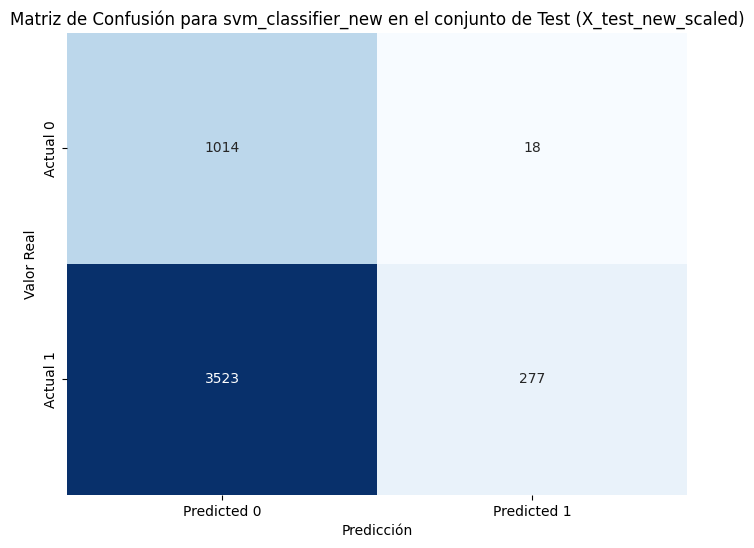

Matriz de Confusión para svm_classifier_new en el conjunto de Test:
[[1014   18]
 [3523  277]]

Classification Report de svm_classifier_new en el conjunto de Test:
              precision    recall  f1-score   support

           0       0.22      0.98      0.36      1032
           1       0.94      0.07      0.14      3800

    accuracy                           0.27      4832
   macro avg       0.58      0.53      0.25      4832
weighted avg       0.79      0.27      0.18      4832


Accuracy de svm_classifier_new en el conjunto de Test: 0.2672


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import pandas as pd

# Hacemos predicción en el X_test_new_scaled set usando svm_classifier_new model
y_pred_new = svm_classifier_new.predict(X_test_new_scaled)

# Generamos la matriz de confusión
cm_new = confusion_matrix(y_test_new, y_pred_new)

# Ploteamos la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Matriz de Confusión para svm_classifier_new en el conjunto de Test (X_test_new_scaled)')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

print("Matriz de Confusión para svm_classifier_new en el conjunto de Test:")
print(cm_new)

# Mostramos el classification report
print("\nClassification Report de svm_classifier_new en el conjunto de Test:")
print(classification_report(y_test_new, y_pred_new))

# Mostramos accuracy
accuracy_new = accuracy_score(y_test_new, y_pred_new)
print(f"\nAccuracy de svm_classifier_new en el conjunto de Test: {accuracy_new:.4f}")

## Para los 6 casos en general

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np

# Asumimos que df_temp_analysis ya esta cargada de celdas anteriores
# Hyperparametros optimos para SVM encontrados anteriormente
best_params_svm = {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

# Enlistamos para almacenar las matrices de confusión y su correspondiente test system_id
confusion_matrices_results = []
system_ids_A = ['A01', 'A02', 'A03', 'A04', 'A05', 'A06']
columns_to_drop = ['system_id', 'label_text', 'audio_file', 'speaker_id']

# Buscamos en cada system_id para ser usado en el set de test (A0X)
for system_id_test_holdout in system_ids_A:
    print(f"-------------------------------------------------------")
    print(f"Processing with system_id '{system_id_test_holdout}' as the holdout test set.")

    # Separamos records con system_id '-' y 'A0X'
    df_dash = df_temp_analysis[df_temp_analysis['system_id'] == '-']

    # Separamos df_dash en 60% train y 40% test
    df_dash_train, df_dash_test = train_test_split(df_dash, test_size=0.4, random_state=42, stratify=df_dash['label_numerical'])

    # Determinamos system_ids para training A-systems
    system_ids_train_A = [sys_id for sys_id in system_ids_A if sys_id != system_id_test_holdout]
    df_train_A_systems = df_temp_analysis[df_temp_analysis['system_id'].isin(system_ids_train_A)]

    # Determinamos A-system para test
    df_test_A_system = df_temp_analysis[df_temp_analysis['system_id'] == system_id_test_holdout]

    # Creamos el nuevo dataset de training
    df_train_new = pd.concat([df_dash_train, df_train_A_systems])

    # Creamos el nuevo dataset de test
    df_test_new = pd.concat([df_dash_test, df_test_A_system])

    # Quitamos las columnas especificas de los nuevos datasets
    df_train_new_processed = df_train_new.drop(columns=columns_to_drop)
    df_test_new_processed = df_test_new.drop(columns=columns_to_drop)

    # Separamos los valores de (X) y de objetivo (y)
    X_train_new = df_train_new_processed.drop('label_numerical', axis=1)
    y_train_new = df_train_new_processed['label_numerical']
    X_test_new = df_test_new_processed.drop('label_numerical', axis=1)
    y_test_new = df_test_new_processed['label_numerical']

    # print(f"Original distribution of classes in y_train_new for '{system_id_test_holdout}': {Counter(y_train_new)}")

    # Aplicamos undersampling a los datos de training
    undersampler = RandomUnderSampler(random_state=42, sampling_strategy='auto')
    X_train_new_resampled, y_train_new_resampled = undersampler.fit_resample(X_train_new, y_train_new)

    # print(f"Distribution of classes in y_train_new after undersampling for '{system_id_test_holdout}': {Counter(y_train_new_resampled)}")

    # Escalamos los datos usando StandardScaler
    scaler_new = StandardScaler()
    X_train_new_resampled_scaled = scaler_new.fit_transform(X_train_new_resampled)
    X_test_new_scaled = scaler_new.transform(X_test_new)

    # Convertimos las matrices escaladas de vuelta a los dataframes conservando los nombres de las columnas
    X_train_new_resampled_scaled = pd.DataFrame(X_train_new_resampled_scaled, columns=X_train_new_resampled.columns)
    X_test_new_scaled = pd.DataFrame(X_test_new_scaled, columns=X_test_new.columns)

    # Entrenamos el SVM model con hyperparametros optimos
    svm_classifier_loop = SVC(
        C=best_params_svm['C'],
        kernel=best_params_svm['kernel'],
        gamma=best_params_svm['gamma'],
        random_state=42, # Para reproducibilidad
        class_weight='balanced' # Para manejar el desbalanceo
    )
    svm_classifier_loop.fit(X_train_new_resampled_scaled, y_train_new_resampled)
    print(f"SVM model trained for test system_id '{system_id_test_holdout}'.")

    # Hacemos predicciones y almacenamos la confusion matrix, y_true, y y_pred
    y_pred_loop = svm_classifier_loop.predict(X_test_new_scaled)
    cm_loop = confusion_matrix(y_test_new, y_pred_loop)
    confusion_matrices_results.append({'system_id': system_id_test_holdout, 'cm': cm_loop, 'y_true': y_test_new, 'y_pred': y_pred_loop})

    # Quitamos el print individual de los classification report para reducir el tamaño del output
    # print(f"\nClassification Report for test system_id '{system_id_test_holdout}':")
    # print(classification_report(y_test_new, y_pred_loop))


# --- Quitando el ploteo y el resumen de esta celda para evitar que se trunque ---
# El ploteo y el resumen sera manejado en una celda diferente para verlo completo


-------------------------------------------------------
Processing with system_id 'A01' as the holdout test set.
SVM model trained for test system_id 'A01'.
-------------------------------------------------------
Processing with system_id 'A02' as the holdout test set.
SVM model trained for test system_id 'A02'.
-------------------------------------------------------
Processing with system_id 'A03' as the holdout test set.
SVM model trained for test system_id 'A03'.
-------------------------------------------------------
Processing with system_id 'A04' as the holdout test set.
SVM model trained for test system_id 'A04'.
-------------------------------------------------------
Processing with system_id 'A05' as the holdout test set.
SVM model trained for test system_id 'A05'.
-------------------------------------------------------
Processing with system_id 'A06' as the holdout test set.
SVM model trained for test system_id 'A06'.



-------------------------------------------------------
Generating combined plot of Confusion Matrices...


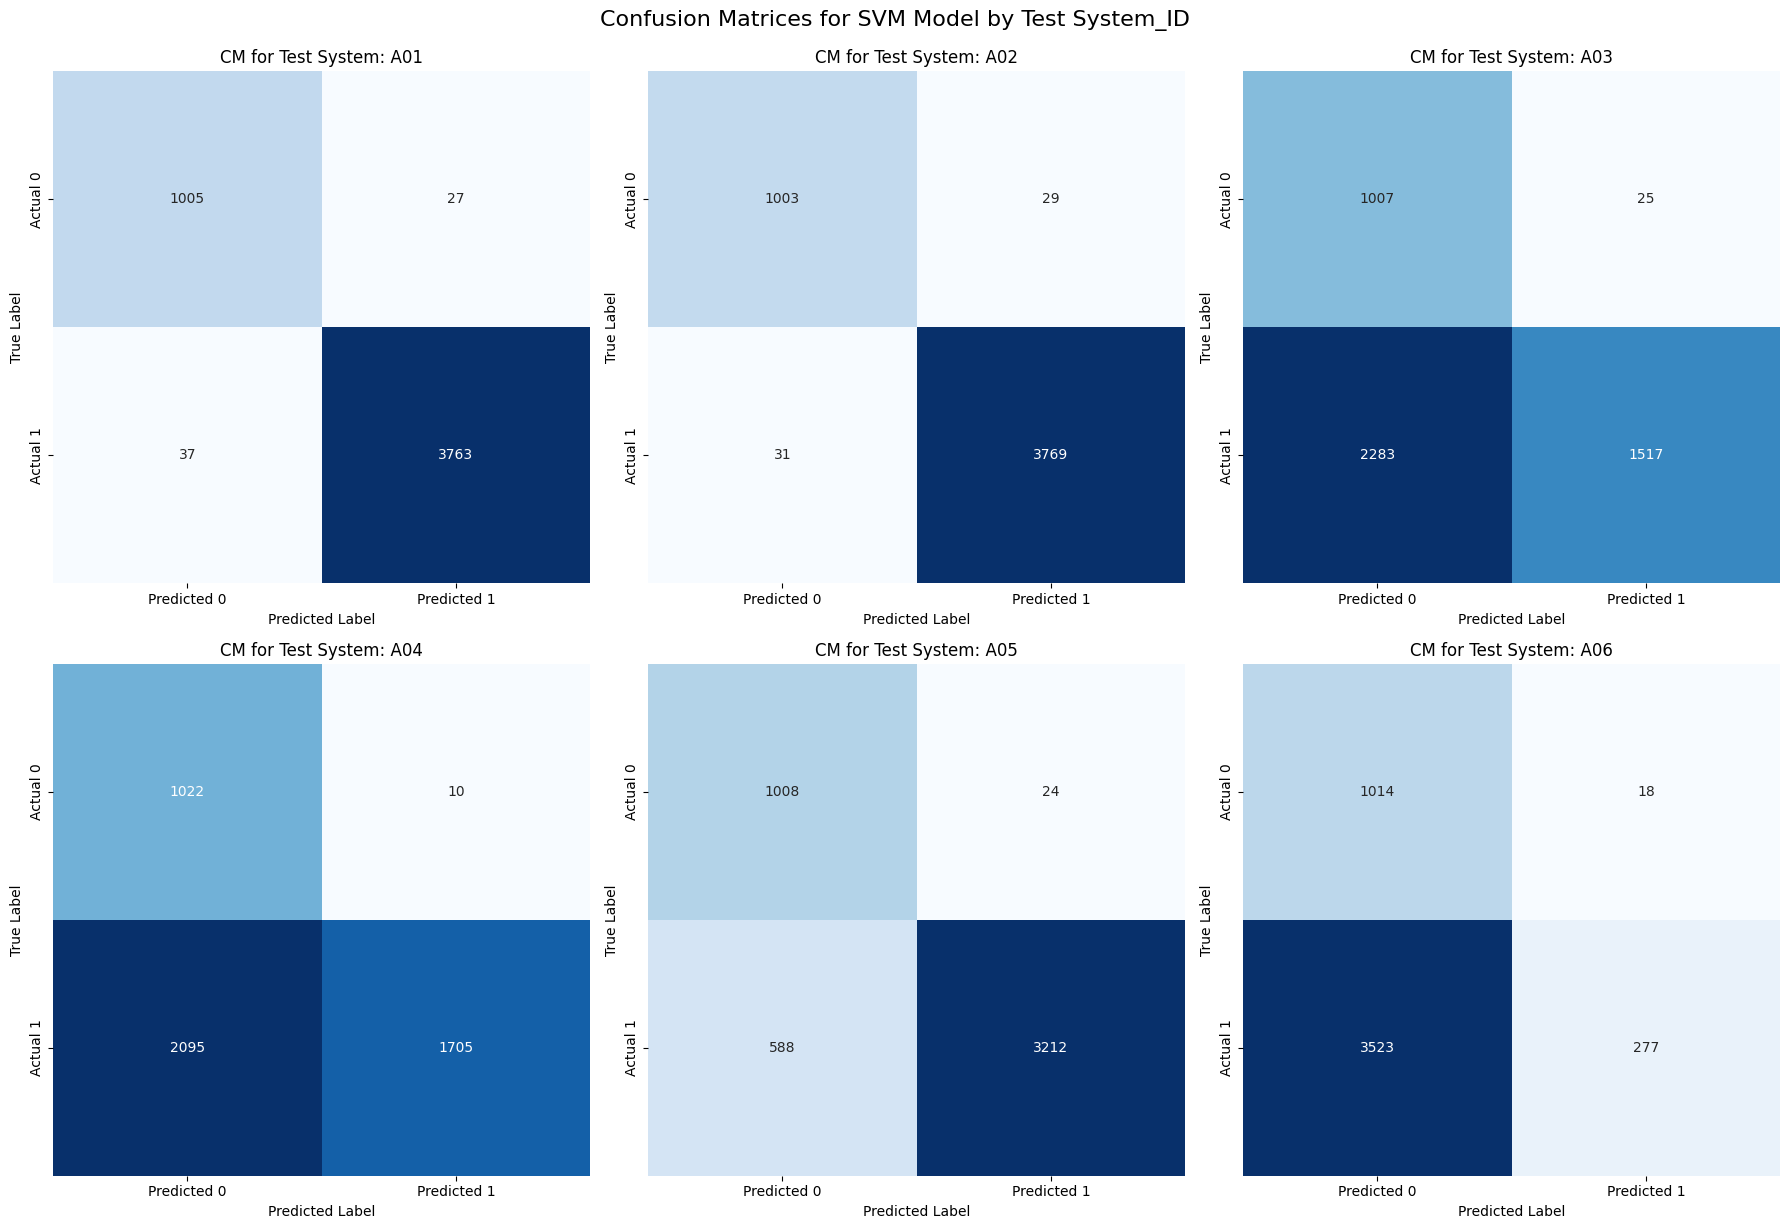

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# --- Ploteamos las matrices de confusión ---
print("\n-------------------------------------------------------")
print("Generating combined plot of Confusion Matrices...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12)) # Creamos matriz 2x3
axes = axes.flatten() # Aplanamos la matriz 2x3 para una mejor interacion

for i, cm_data in enumerate(confusion_matrices_results):
    system_id = cm_data['system_id']
    cm = cm_data['cm']

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'],
                ax=axes[i])
    axes[i].set_title(f'CM for Test System: {system_id}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.suptitle('Confusion Matrices for SVM Model by Test System_ID', y=1.02, fontsize=16)
plt.show()

Se observa que, según el sistema de generación, hay algunos que se detectan muy bien a partir de datos entrenados con el resto y otros que no.

- A01 y A02 se detectan casi igual que cuando estaban incluidos en el conjunto de train.
- A05 disminuye ligeramente su detección al excluirlo del conjunto de train, pero sigue siendo razonablemente buena.
- A03 y A04 empeoran drásticamente, no detectándose más de la mitad de los audios fake (peor que un RandomClassifier).
- A06 no es prácticamente detectado sino está en el set de train. Esto es un grave problema que merecería un estudio más particular, pero por ahora podríamos decir que es un sistema de generación de voz que parece tener una naturaleza distinta a los otros 5, ya que no es detectable por un modelo que solo haya visto a los otros 5.

# Propuestas de mejora:

- Probar otro tipo de optimización de hiperparámetros (Optuna, RandomSearch, ...).
- Probar otro tipo de balanceo de datos (oversampling con SMOTE u otras técnicas).
- Probar otro tipo de escalado de los datos (RobustScaler, ...)
- Analizar la importancia de las features, de forma que seguramente se pueda reducir el número de features del modelo sin impactar a su performance.
- Explorar otros tipos de objetivos (como reducir el número de falsos positivos o reducir el número total de falsos).
- Explorar más en detalle la no detección de A06 cuando no está en el dataset de entrenamiento.